In [42]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load the data
# file_path = './mspus.csv'

# data = pd.read_csv(file_path, parse_dates=['DATE']) \
#     .loc[lambda df: df['DATE'] > pd.Timestamp('2000-01-01')]

# # Plot the data
# plt.figure(figsize=(12, 6))
# plt.plot(data['DATE'], data['MSPUS'], label='Median Sale Price (USD)')
# plt.title('Median Sale Price of Houses in the U.S. Over Time')
# plt.xlabel('Date')
# plt.ylabel('Median Sale Price (USD)')
# plt.legend()
# plt.grid(True)
# plt.show()

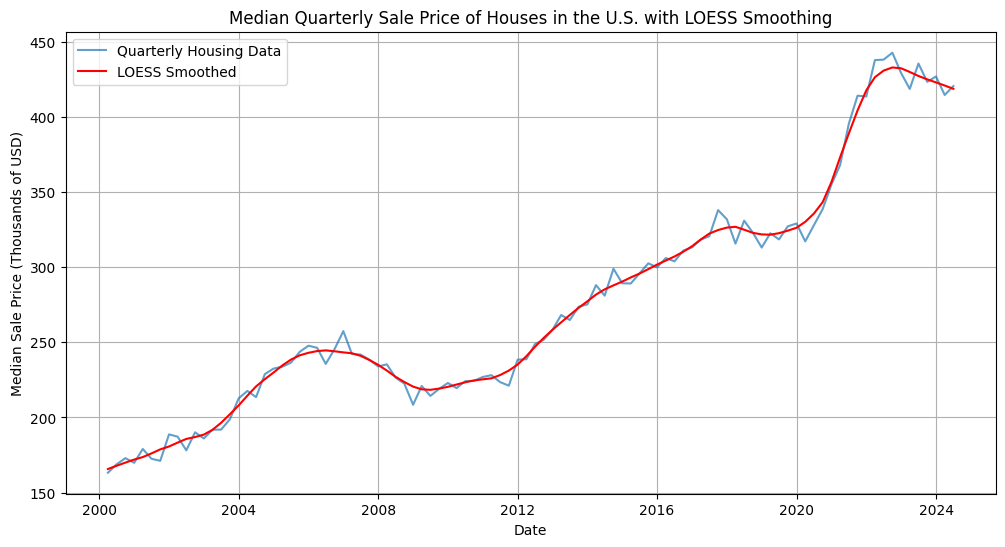

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load the data
file_path = './mspus.csv'
data = pd.read_csv(file_path, parse_dates=['DATE']) \
    .loc[lambda df: df['DATE'] > pd.Timestamp('2000-01-01')]

# Scale the price to thousands of dollars
data['MSPUS'] = data['MSPUS'] / 1000

# Apply LOESS smoothing
loess_smoothed = lowess(data['MSPUS'], data['DATE'], frac=0.1)  # Adjust 'frac' for smoothing level

# Plot the original data and LOESS smoothed line
plt.figure(figsize=(12, 6))
plt.plot(data['DATE'], data['MSPUS'], label='Quarterly Housing Data', alpha=0.7)
plt.plot(data['DATE'], loess_smoothed[:, 1], label='LOESS Smoothed', color='red')
plt.title('Median Quarterly Sale Price of Houses in the U.S. with LOESS Smoothing')
plt.xlabel('Date')
plt.ylabel('Median Sale Price (Thousands of USD)')
plt.legend()
plt.grid(True)
plt.show()

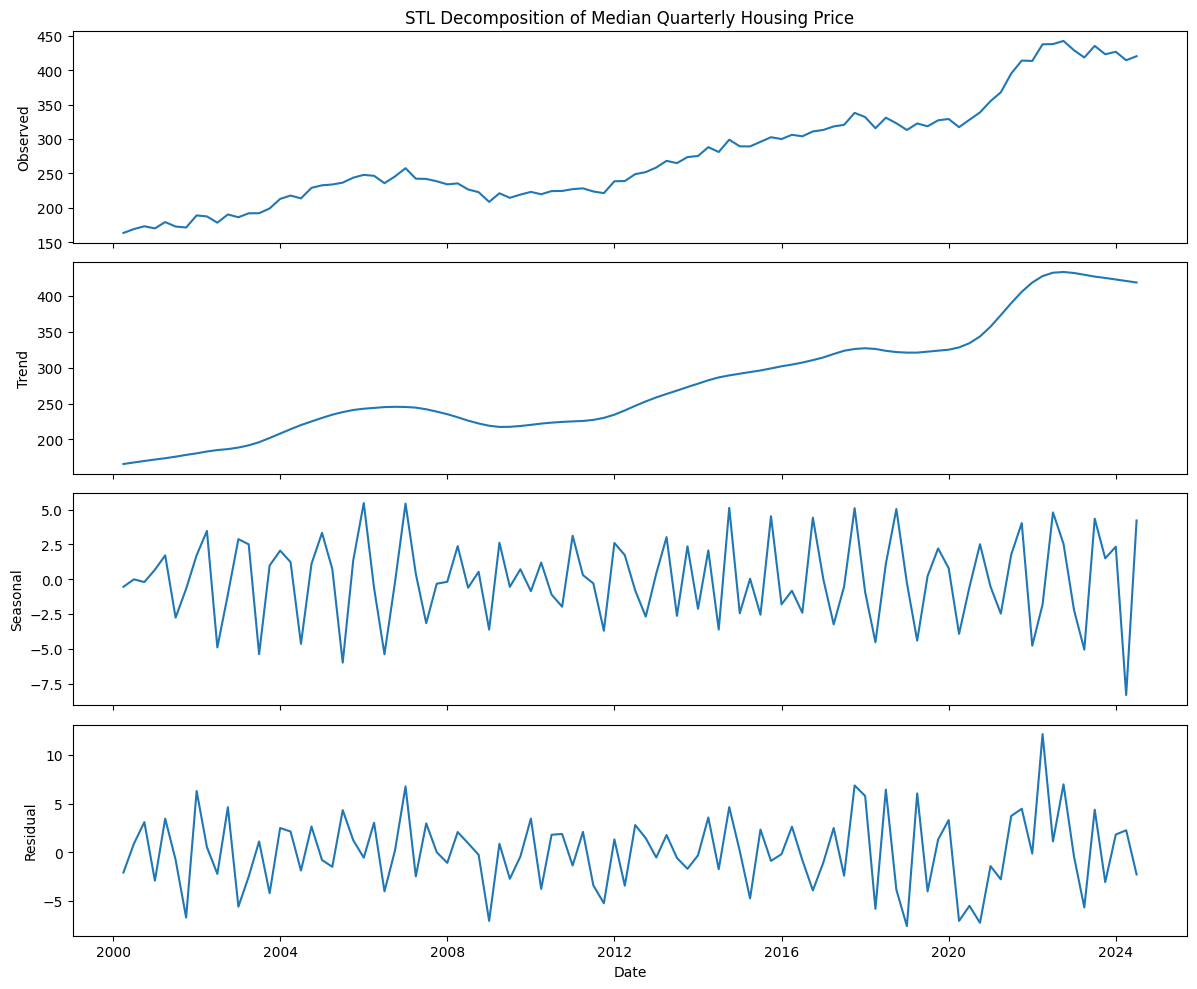

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Load the data
file_path = './mspus.csv'
data = pd.read_csv(file_path, parse_dates=['DATE']) \
    .loc[lambda df: df['DATE'] > pd.Timestamp('2000-01-01')]

# Scale the price to thousands of dollars
data['MSPUS'] = data['MSPUS'] / 1000

# Set DATE as the index for time series analysis
data.set_index('DATE', inplace=True)

# Perform STL decomposition with seasonal=5 for quarterly data
stl = STL(data['MSPUS'], seasonal=5)
result = stl.fit()

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
ax1.plot(result.observed)
ax1.set_ylabel('Observed')
ax1.set_title('STL Decomposition of Median Quarterly Housing Price')

ax2.plot(result.trend)
ax2.set_ylabel('Trend')

ax3.plot(result.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(result.resid)
ax4.set_ylabel('Residual')
ax4.set_xlabel('Date')

plt.tight_layout()
plt.show()

1


/var/folders/gb/trvj_2v15pl3fy6jg40wrk1w0000gn/T/ipykernel_77598/2068619178.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CBBTCUSD'].interpolate(method='linear', inplace=True)  # Fill NaNs with linear interpolation


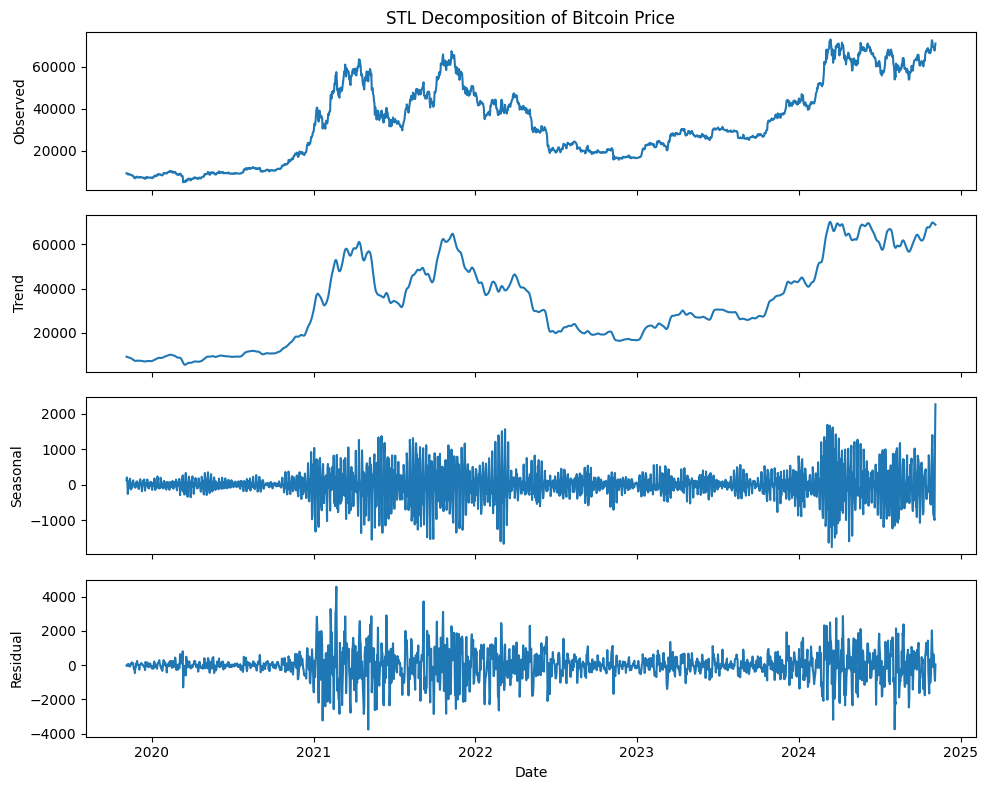

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Load the data
file_path = './bitcoin.csv'
data = pd.read_csv(file_path, parse_dates=['DATE'])

# Convert CBBTCUSD column to numeric, setting errors='coerce' to handle any non-numeric entries
data['CBBTCUSD'] = pd.to_numeric(data['CBBTCUSD'], errors='coerce')

# Check for any missing values and handle them if needed (e.g., interpolate)
print(data['CBBTCUSD'].isnull().sum())  # Check if there are any NaNs after conversion
data['CBBTCUSD'].interpolate(method='linear', inplace=True)  # Fill NaNs with linear interpolation

# Perform STL decomposition
data.set_index('DATE', inplace=True)
stl = STL(data['CBBTCUSD'], seasonal=7)
result = stl.fit()

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax1.plot(result.observed)
ax1.set_ylabel('Observed')
ax1.set_title('STL Decomposition of Bitcoin Price')

ax2.plot(result.trend)
ax2.set_ylabel('Trend')

ax3.plot(result.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(result.resid)
ax4.set_ylabel('Residual')
ax4.set_xlabel('Date')

plt.tight_layout()
plt.show()

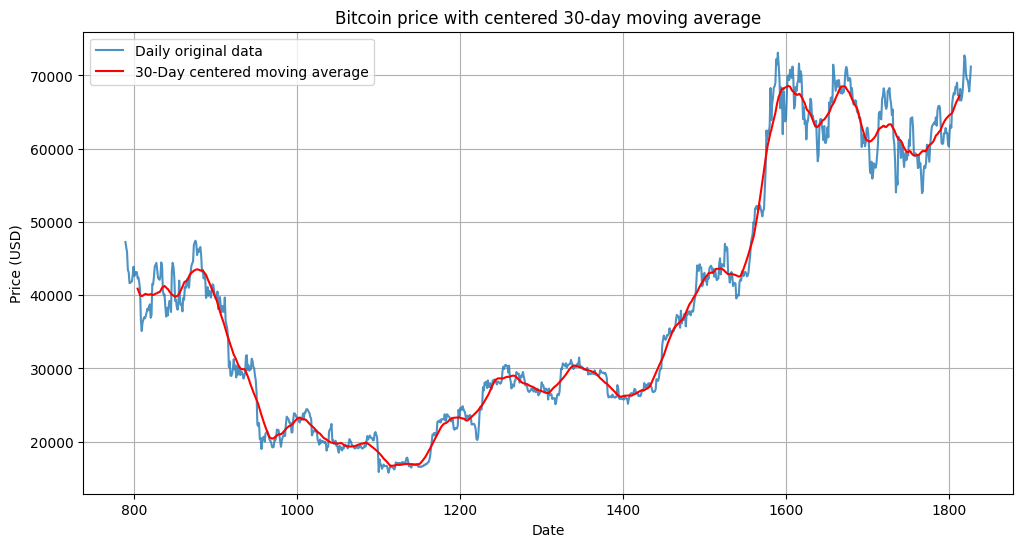

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load the data
file_path = './bitcoin.csv'
data = pd.read_csv(file_path, parse_dates=['DATE'])

# Convert CBBTCUSD column to numeric, setting errors='coerce' to handle any non-numeric entries
data['CBBTCUSD'] = pd.to_numeric(data['CBBTCUSD'], errors='coerce')
data = data[data['DATE'] > pd.Timestamp('2022-01-01')]

loess_smoothed = lowess(data['CBBTCUSD'], data.index, frac=0.05)

# Calculate a 30-day centered moving average
data['30_day_MA'] = data['CBBTCUSD'].rolling(window=30, center=True).mean()

# Plot the original data, LOESS smoothed line, and 30-day centered moving average
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['CBBTCUSD'], label='Daily original data', alpha=0.8)
# plt.plot(data.index, loess_smoothed[:, 1], label='LOESS Smoothed', color='red')
plt.plot(data.index, data['30_day_MA'], label='30-Day centered moving average', color='red')
plt.title('Bitcoin price with centered 30-day moving average')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


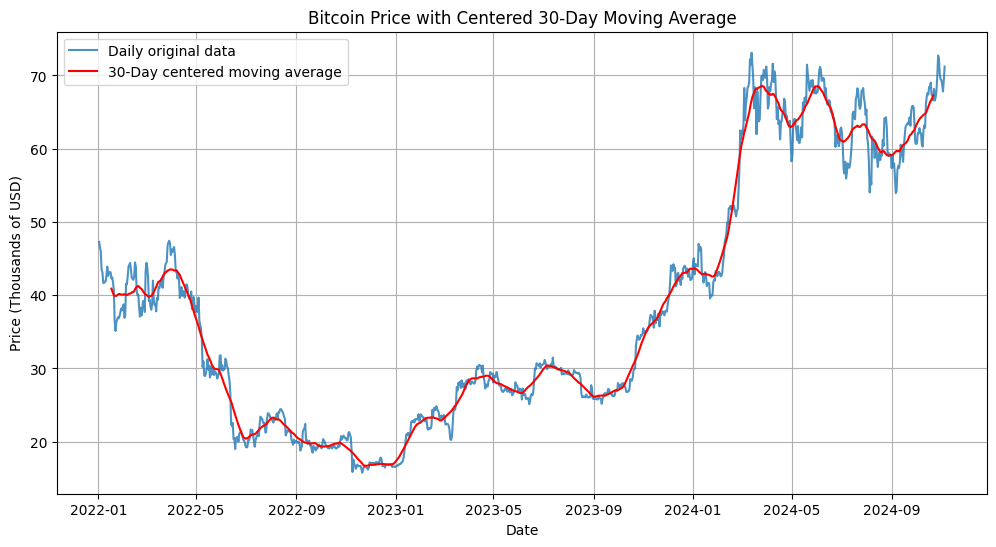

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# Load the data
file_path = './bitcoin.csv'
data = pd.read_csv(file_path, parse_dates=['DATE'])

# Convert CBBTCUSD column to numeric, setting errors='coerce' to handle any non-numeric entries
data['CBBTCUSD'] = pd.to_numeric(data['CBBTCUSD'], errors='coerce')
data = data[data['DATE'] > pd.Timestamp('2022-01-01')]

# Scale the price to thousands of dollars
data['CBBTCUSD'] = data['CBBTCUSD'] / 1000

# Set DATE as the index for time series analysis
data.set_index('DATE', inplace=True)

# Apply LOESS smoothing
loess_smoothed = lowess(data['CBBTCUSD'], data.index, frac=0.05)

# Calculate a 30-day centered moving average
data['30_day_MA'] = data['CBBTCUSD'].rolling(window=30, center=True).mean()

# Plot the original data, LOESS smoothed line, and 30-day centered moving average
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['CBBTCUSD'], label='Daily original data', alpha=0.8)
plt.plot(data.index, data['30_day_MA'], label='30-Day centered moving average', color='red')
plt.title('Bitcoin Price with Centered 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price (Thousands of USD)')
plt.legend()
plt.grid(True)
plt.show()